In [ ]:
# Modules we'll use
import pandas as pd
import numpy as np

# For Box-Cox Transformation
from scipy import stats

# For min_max scaling
from mlxtend.preprocessing import minmax_scaling

# Plotting modules
import seaborn as sns
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(0)

# Scaling vs. Normalization: What's the difference?

* In scaling, you're changing the **range** of your data, while
* In normalization, you're changing the **shape of the distribution** of your data.

# Scaling

This means that you're transforming your data so that it fits within a specific scale, like 0-100 or 0-1.

You want to scale data when you're using methods based on measures of how far apart data points are, like support vector machines (SVM) or k-nearest neighbors (KNN).

With these algorithms, a change of "1" in any numeric feature is given the same importance.

Notice in the below grpahs how the shape of the data doesn't change, but that instead of ranging from 0 to 8ish, it now ranges from 0 to 1.

<function matplotlib.pyplot.show(close=None, block=None)>

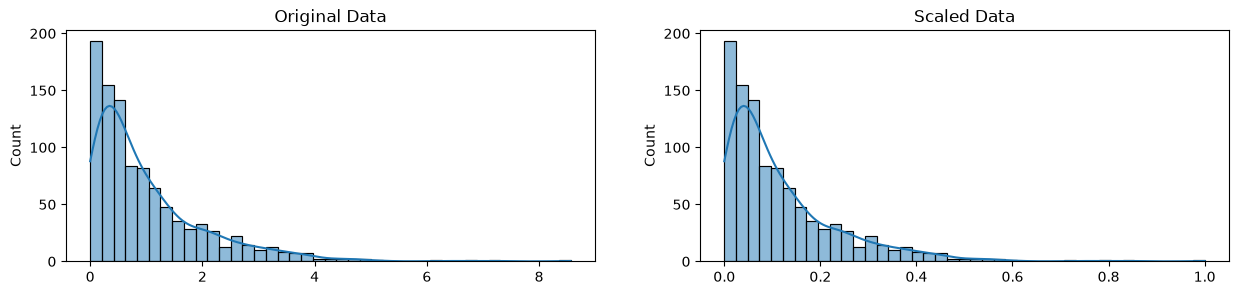

In [ ]:
# Generate 1000 data points randomly drawn from an exponential distribution
original_data = np.random.exponential(size=1000)

# mix-max scale the data between 0 and 1
# xscaled = (x - xmin) / (xmax - xmin)
# The smallest value becomes 0, the largest value becomes 1, and all other values are scaled proportionally in between
scaled_data = minmax_scaling(original_data, columns=[0])

# Plot both together to compare
# Creates a figure with 1 row, 2 columns, with the size of 15 inches by 3 inches
fig, ax = plt.subplots(1, 2, figsize=(15, 3))

# ax=ax[0] → put it in the left plot; kde=True → add a smooth KDE (kernel density estimate) curve; legend=False → don't show a legend
sns.histplot(original_data, ax=ax[0], kde=True, legend=False)

ax[0].set_title('Original Data')
sns.histplot(scaled_data, ax=ax[1], kde=True, legend=False)
ax[1].set_title('Scaled Data')
plt.show()

# Normalization

The point of normalization is to change your observations so that they can be described as a normal distribution.

Normal (Gaussian) distribution: Also known as the "bell curve",  is a specific statistical distribution where a roughly equal observations fall above and below the mean, the mean and the median are the same, and there are more observations closer to the mean.

In general, you'll normalize your data if you're going to be using a machine learning or statistics technique that assumes your data is normally distributed.

Some examples of these include linear discriminant analysis (LDA) and Gaussian naive Bayes. (Pro tip: any method with "Gaussian" in the name probably assumes normality.)

Below is an example of Box-Cow Transformation, which reduce skewness and make its distribution more approximately normal.

```text
Skewed distribution
      ↓
change the SHAPE
      ↓
more symmetric / normal-like distribution
```

So if you have:

```text
Exponential data
████████
████
██
█
█
█
```

Box-Cox might transform it into something closer to:

```text
       █
      ███
     █████
   █████████
     █████
      ███
       █
```

Notice that the shape of our data has changed. Before normalizing it was almost L-shaped. But after normalizing it looks more like the outline of a bell (hence "bell curve").

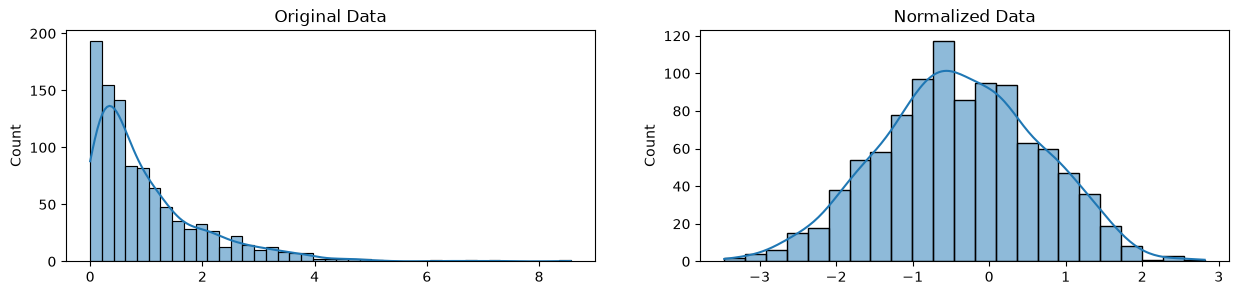

In [ ]:
# Normalize the exponential data with boxcox
normalized_data = stats.boxcox(original_data)

# Plot both together to compare
fig, ax = plt.subplots(1, 2, figsize=(15, 3))
sns.histplot(original_data, ax=ax[0], kde=True, legend=False)
ax[0].set_title('Original Data')
sns.histplot(normalized_data[0], ax=ax[1], kde=True, legend=False)
ax[1].set_title('Normalized Data')
plt.show()

Standard Box-Cox requires strictly positive values (x > 0). If your data contains zero or negative values, you'd typically need to shift the data first or use a related transformation such as Yeo-Johnson, which can handle zero and negative values.

| Problem                                                 | Possible solution                  |
| ------------------------------------------------------- | ---------------------------------- |
| Features have wildly different ranges                   | Min-max scaling / standardization  |
| Variable is heavily skewed                              | Box-Cox / Yeo-Johnson / log        |
| Relationship isn't linear                               | Transformation or nonlinear model  |
| Variance increases with the mean                        | Transformation such as log/Box-Cox |
| Model requires approximately normal residuals           | Transformation may help            |
| You simply want to understand the original distribution | **Don't transform it**             |
